## Causal Comparator: Quickstart Guide

This notebook serves as a practical introduction to the <b>causal comparator</b> package, a tool designed to identify and evaluate structural changes between two causal systems (DAGs).

Whether you are comparing a "Reference" system to a "Treatment" system or monitoring a process over time, this framework helps you distinguish real causal shifts from statistical noise caused by sample size imbalances.

In [26]:
from causal_comparator.data_generation import EdgePerturbationSimulator
import numpy as np
from causal_comparator.discovery import CausalComparator
import lingam 
from lingam.utils import make_dot

In [7]:
# Helper for un-shuffling matrices if your simulator shuffles nodes
def align_matrix(B_est, p):
    idx = np.argsort(p)
    return B_est[idx, :][:, idx]

In [ ]:
# Initialize Simulator
n_nodes = 10
simulator = EdgePerturbationSimulator(n_nodes=n_nodes, noise_type="uniform", rng=np.random.default_rng(42))

# Create graphs: B1_true is the original, B2_true is the modified version as in [1] and [2]
# delta_true marks the exact edges that were removed (edges in B1 not in B2)
B1_true, B2_true, delta_true = simulator.create_graphs(edge_prob=0.2, n_positives=2)

# Generate synthetic data (N1=1000, N2=100) according to [2]
df1, p1 = simulator.simulate_data(B1_true, n_samples=1000)
df2, p2 = simulator.simulate_data(B2_true, n_samples=100)

print(f"Generated data for {n_nodes} nodes.")
print(f"System 1: {df1.shape[0]} samples | System 2: {df2.shape[0]} samples")

Generated data for 10 nodes.
System 1: 1000 samples | System 2: 100 samples


In [20]:
# Initialize Causal Comparator
comparator = CausalComparator(data_i=df1, data_j=df2, model_class=lingam.DirectLiNGAM)


In [33]:
# Execute Naive Estimation
comparator.estimate_naive()
# Align and Binarize
B1_naive = align_matrix(comparator.freq_i, p1)
B2_naive = align_matrix(comparator.freq_j, p2)

# Correct Logic for Naive: Binary indicator of Removal
# 1 if edge is in B1 and NOT in B2, else 0 [1]
delta_naive = ((B1_naive == 1) & (B2_naive == 0)).astype(int)

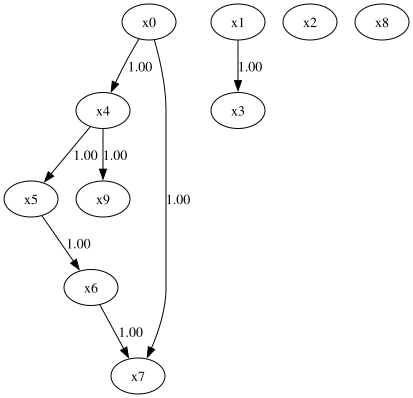

In [34]:
make_dot(B1_naive)

In [40]:
#make_dot(B1_true)

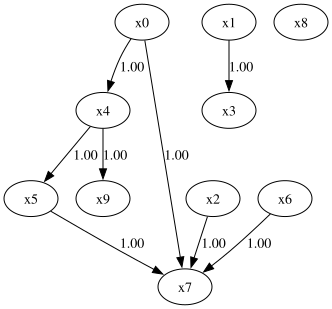

In [36]:
make_dot(B2_naive)

In [39]:
#make_dot(B2_true)

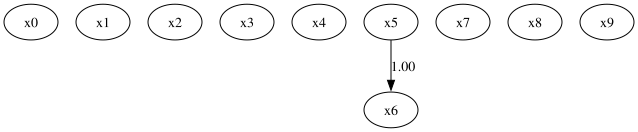

In [38]:
make_dot(delta_naive)

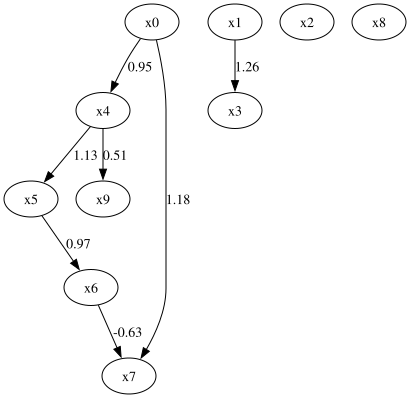

In [30]:
#B1_true, B2_true, delta_true
make_dot(B1_true)

In [ ]:
# Method 3: RSBS (Equal sample-size resampling - Recommended)
comparator.estimate_rsbs(n_sampling=10, seed=42)
# Align the resulting frequency matrices back to the canonical node order
B1_aligned = align_matrix(comparator.freq_i, p1)
B2_aligned = align_matrix(comparator.freq_j, p2)

# Calculate the Delta Score (Selection Probability Difference)
delta_scores = B1_aligned - B2_aligned

## References
[1] Ma, Sisi, and Roshan Tourani. "Comparing Causal Bayesian Networks Estimated from Data." Entropy 26.3 (2024): 228.

[2] Shimizu, Shohei, et al. "DirectLiNGAM: A direct method for learning 
a linear non-Gaussian structural equation model." Journal of Machine 
Learning Research-JMLR 12.Apr (2011): 1225-1248.